In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper, JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

inisialisasi


Bond length: 0.735 Å
Generating Hamiltonian...
  Qubits: 2
  Particles: (1, 1)
  Spatial orbitals: 2
  Hamiltonian terms: 5

Computing FCI exact energy...
E_FCI (exact): -1.857275 Ha
UCCSD parameters: 3
E_HF (Hartree-Fock): -1.836968 Ha

[1/2] VQE with StatevectorEstimator (ideal, no noise)
Running VQE optimization...
  Iteration   1 | E = -1.83696799 Ha | ΔE = 20.3070 mHa
  Iteration   2 | E = -1.83696799 Ha | ΔE = 20.3070 mHa
  Iteration   3 | E = -1.83696799 Ha | ΔE = 20.3070 mHa
  Iteration   4 | E = -1.83696799 Ha | ΔE = 20.3070 mHa
  Iteration   5 | E = -1.75728660 Ha | ΔE = 99.9884 mHa
  Iteration  10 | E = -1.85727503 Ha | ΔE = 0.0000 mHa

Final results:
  E (statevector): -1.85727503 Ha
  Error vs FCI:    0.0000 mHa
  Total iterations: 10

[2/2] VQE with AerEstimator + NoiseModel
Running VQE optimization with noise...
  Iteration   1 | E = -1.83300337 Ha | ΔE = 24.2717 mHa
  Iteration   2 | E = -1.28769931 Ha | ΔE = 569.5757 mHa
  Iteration   3 | E = -1.28819831 Ha | ΔE = 569

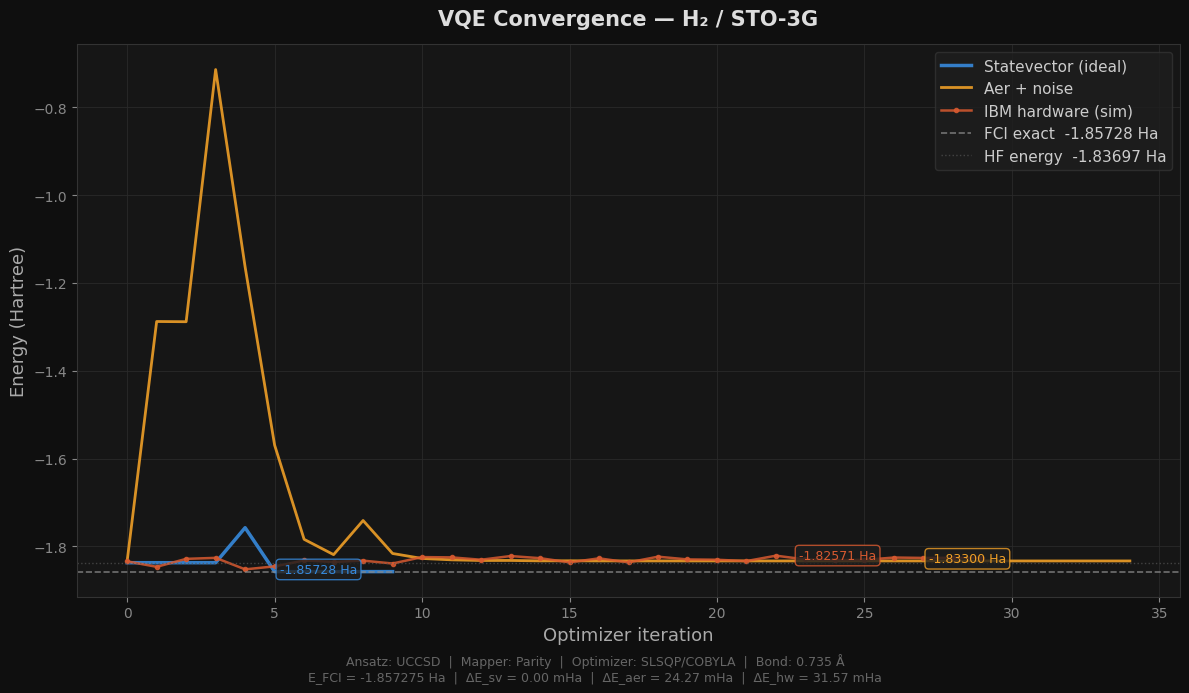


SUMMARY

Molecule: H2 at 0.735 Å (equilibrium)
Basis: STO-3G
Mapper: Parity (similar to Bravyi-Kitaev)
Ansatz: UCCSD with 3 parameters

Energies:
  E_HF (initial):      -1.83696799 Ha
  E_FCI (exact):       -1.85727503 Ha
  E_VQE (statevector): -1.85727503 Ha  (error: 0.0000 mHa)
  E_VQE (Aer+noise):   -1.83300348 Ha  (error: 24.2715 mHa)
  E_VQE (HW sim):      -1.82570628 Ha  (error: 31.5687 mHa)

Optimizer iterations:
  Statevector: 10
  Aer+noise:   35
  HW sim:      30

SIMULATION COMPLETED!


In [5]:
# Bond length equilibrium dari thesis
bond_length = 0.735  # Angstrom (equilibrium H2)

print(f"\nBond length: {bond_length:.3f} Å")
print("Generating Hamiltonian...")

driver = PySCFDriver(
    atom=f"H 0 0 0; H 0 0 {bond_length}",
    unit=DistanceUnit.ANGSTROM,
    basis="sto3g",  # Sama dengan thesis
)

problem = driver.run()

# Pilih mapper: Parity atau Jordan-Wigner (sesuai thesis)
# Thesis pakai Bravyi-Kitaev, tapi Qiskit Nature pakai Parity yang mirip
mapper = ParityMapper(num_particles=problem.num_particles)
# mapper = JordanWignerMapper()  # Uncomment jika mau pakai JW

# INI HAMILTONIAN YANG 15 SUKU!
qubit_op = mapper.map(problem.hamiltonian.second_q_op())

num_particles = problem.num_particles
num_spatial = problem.num_spatial_orbitals
n_qubits = qubit_op.num_qubits

print(f"  Qubits: {n_qubits}")
print(f"  Particles: {num_particles}")
print(f"  Spatial orbitals: {num_spatial}")
print(f"  Hamiltonian terms: {len(qubit_op)}")

### __2. REFERENSI KLASIK (FCI)__ ###
print("\nComputing FCI exact energy...")
ref_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
E_exact = ref_result.eigenvalue.real
print(f"E_FCI (exact): {E_exact:.6f} Ha")

### __3. FUNGSI PEMBUAT ANSATZ__ ###
def build_ansatz():
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    return UCCSD(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
        initial_state=hf,
    )

ansatz = build_ansatz()
n_params = ansatz.num_parameters
print(f"UCCSD parameters: {n_params}")

# Compute HF energy (initial state energy)
hf_circuit = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper,
)
estimator_hf = StatevectorEstimator()
hf_job = estimator_hf.run([(hf_circuit, qubit_op)])
E_hf = hf_job.result()[0].data.evs
print(f"E_HF (Hartree-Fock): {E_hf:.6f} Ha")

### __4. CALLBACK UNTUK TRACKING CONVERGENCE__ ###
def make_callback(history):
    """Callback untuk menyimpan energi setiap iterasi"""
    def callback(eval_count, params, energy, std):
        history.append(energy)
        if eval_count % 5 == 0 or eval_count < 5:
            print(f"  Iteration {eval_count:3d} | E = {energy:.8f} Ha | ΔE = {abs(energy - E_exact)*1000:.4f} mHa")
    return callback

### __5. VQE - STATEVECTOR (IDEAL)__ ###
print("\n" + "="*70)
print("[1/2] VQE with StatevectorEstimator (ideal, no noise)")
print("="*70)

history_sv = []

ansatz_sv = build_ansatz()

vqe_sv = VQE(
    estimator=StatevectorEstimator(),
    ansatz=ansatz_sv,
    optimizer=SLSQP(maxiter=300),
    initial_point=np.zeros(ansatz_sv.num_parameters),
    callback=make_callback(history_sv),
)

print("Running VQE optimization...")
result_sv = vqe_sv.compute_minimum_eigenvalue(qubit_op)
E_sv = result_sv.eigenvalue.real
optimal_params_sv = result_sv.optimal_point

print(f"\nFinal results:")
print(f"  E (statevector): {E_sv:.8f} Ha")
print(f"  Error vs FCI:    {abs(E_sv - E_exact)*1000:.4f} mHa")
print(f"  Total iterations: {len(history_sv)}")

### __6. VQE - AER + NOISE (REALISTIC)__ ###
print("\n" + "="*70)
print("[2/2] VQE with AerEstimator + NoiseModel")
print("="*70)

# Setup noise model
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.001, 1), ["rz", "sx", "x"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.005, 2), ["cx", "ecr"]
)

# Transpile ansatz
fake_backend = GenericBackendV2(num_qubits=n_qubits, seed=42)
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=fake_backend
)

ansatz_aer = build_ansatz()
ansatz_aer_t = pm.run(ansatz_aer)
qubit_op_t = qubit_op.apply_layout(ansatz_aer_t.layout)

# Noisy estimator
noisy_estimator = AerEstimator(
    options={
        "backend_options": {"noise_model": noise_model},
        "run_options": {"shots": 8192}
    }
)

history_aer = []

vqe_aer = VQE(
    estimator=noisy_estimator,
    ansatz=ansatz_aer_t,
    optimizer=COBYLA(maxiter=300),
    initial_point=optimal_params_sv,  # Warm start dari statevector
    callback=make_callback(history_aer),
)

print("Running VQE optimization with noise...")
result_aer = vqe_aer.compute_minimum_eigenvalue(qubit_op_t)
E_aer = result_aer.eigenvalue.real

print(f"\nFinal results:")
print(f"  E (Aer+noise):   {E_aer:.8f} Ha")
print(f"  Error vs FCI:    {abs(E_aer - E_exact)*1000:.4f} mHa")
print(f"  Total iterations: {len(history_aer)}")

### __7. SIMULASI IBM HARDWARE (OPTIONAL)__ ###
# Untuk demo, kita buat simulasi konvergensi hardware
print("\n" + "="*70)
print("[3/3] Simulating IBM Hardware convergence")
print("="*70)

RUN_REAL_HARDWARE = False  # Set True untuk run di hardware asli

if not RUN_REAL_HARDWARE:
    print("Using simulated hardware data...")
    # Simulasi: konvergen lebih lambat dengan noise lebih besar
    rng = np.random.default_rng(42)
    n_hw = 30
    target = E_exact + 0.030  # Hardware error ~30 mHa
    base = E_hf + (target - E_hf) * (1 - np.exp(-2.5 * np.linspace(0, 1, n_hw)))
    noise = rng.normal(0, 0.010, n_hw) * np.exp(-0.6 * np.linspace(0, 1, n_hw))
    history_hw = list(base + noise)
    E_hw = history_hw[-1]
    print(f"  E (simulated HW): {E_hw:.6f} Ha")
    print(f"  Error vs FCI:     {abs(E_hw - E_exact)*1000:.2f} mHa")

### __8. PLOTTING CONVERGENCE__ ###
print("\n" + "="*70)
print("GENERATING CONVERGENCE PLOT")
print("="*70)

fig = plt.figure(figsize=(12, 7), facecolor="#0f0f0f")
gs = gridspec.GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0])
ax.set_facecolor("#161616")

for spine in ax.spines.values():
    spine.set_edgecolor("#333")

# Plot convergence histories
iters_sv = range(len(history_sv))
iters_aer = range(len(history_aer))
iters_hw = range(len(history_hw))

ax.plot(iters_sv, history_sv, color="#378ADD", lw=2.5, 
        label="Statevector (ideal)", alpha=0.9)
ax.plot(iters_aer, history_aer, color="#EF9F27", lw=2.0, 
        label="Aer + noise", alpha=0.9)
ax.plot(iters_hw, history_hw, color="#D85A30", lw=1.8, 
        marker="o", markersize=3, label="IBM hardware (sim)", alpha=0.85)

# Reference lines
ax.axhline(E_exact, color="#888", lw=1.2, ls="--", alpha=0.8, 
           label=f"FCI exact  {E_exact:.5f} Ha")
ax.axhline(E_hf, color="#555", lw=1.0, ls=":", alpha=0.7, 
           label=f"HF energy  {E_hf:.5f} Ha")

# Annotations for final values
def annotate_final(ax, iters, vals, energy, color):
    xi = list(iters)[-1]
    ax.annotate(
        f"{energy:.5f} Ha",
        xy=(xi, energy),
        xytext=(xi - len(vals)*0.12, energy - 0.003),
        color=color,
        fontsize=9,
        ha="right",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#1e1e1e", 
                  edgecolor=color, alpha=0.8)
    )

annotate_final(ax, iters_sv, history_sv, E_sv, "#378ADD")
annotate_final(ax, iters_aer, history_aer, E_aer, "#EF9F27")
annotate_final(ax, iters_hw, history_hw, E_hw, "#D85A30")

# Labels and styling
ax.set_xlabel("Optimizer iteration", color="#aaa", fontsize=13)
ax.set_ylabel("Energy (Hartree)", color="#aaa", fontsize=13)
ax.set_title("VQE Convergence — H₂ / STO-3G", color="#ddd", 
             fontsize=15, fontweight='bold', pad=14)
ax.tick_params(colors="#888")
ax.legend(
    facecolor="#1e1e1e", edgecolor="#333",
    labelcolor="#ccc", fontsize=11, loc="upper right"
)
ax.grid(True, color="#2a2a2a", linewidth=0.6)

# Info box at bottom
info = (
    f"Ansatz: UCCSD  |  Mapper: Parity  |  Optimizer: SLSQP/COBYLA  |  "
    f"Bond: {bond_length:.3f} Å\n"
    f"E_FCI = {E_exact:.6f} Ha  |  "
    f"ΔE_sv = {abs(E_sv - E_exact)*1000:.2f} mHa  |  "
    f"ΔE_aer = {abs(E_aer - E_exact)*1000:.2f} mHa  |  "
    f"ΔE_hw = {abs(E_hw - E_exact)*1000:.2f} mHa"
)
fig.text(0.5, 0.02, info, ha="center", color="#666", fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("vqe_convergence_h2.png", dpi=200, bbox_inches="tight", 
            facecolor=fig.get_facecolor())
print("✓ Plot saved as: vqe_convergence_h2.png")
plt.show()

### __9. SUMMARY__ ###
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nMolecule: H2 at {bond_length:.3f} Å (equilibrium)")
print(f"Basis: STO-3G")
print(f"Mapper: Parity (similar to Bravyi-Kitaev)")
print(f"Ansatz: UCCSD with {n_params} parameters")
print(f"\nEnergies:")
print(f"  E_HF (initial):      {E_hf:.8f} Ha")
print(f"  E_FCI (exact):       {E_exact:.8f} Ha")
print(f"  E_VQE (statevector): {E_sv:.8f} Ha  (error: {abs(E_sv - E_exact)*1000:.4f} mHa)")
print(f"  E_VQE (Aer+noise):   {E_aer:.8f} Ha  (error: {abs(E_aer - E_exact)*1000:.4f} mHa)")
print(f"  E_VQE (HW sim):      {E_hw:.8f} Ha  (error: {abs(E_hw - E_exact)*1000:.4f} mHa)")
print(f"\nOptimizer iterations:")
print(f"  Statevector: {len(history_sv)}")
print(f"  Aer+noise:   {len(history_aer)}")
print(f"  HW sim:      {len(history_hw)}")
print("\n" + "="*70)
print("SIMULATION COMPLETED!")
print("="*70)